In [49]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

### Charger l'ensemble de données MNIST

In [50]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Print shapes to understand the dataset structure
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


### Prétraitement des données pour un réseau neuronal entièrement connecté

In [51]:
# Flatten images from 28x28 to 784 pixels
x_train_flattened = x_train.reshape(x_train.shape[0], -1)
x_test_flattened = x_test.reshape(x_test.shape[0], -1)

# Normalize pixel values by dividing by 255
x_train_normalized = x_train_flattened.astype('float32') / 255.0
x_test_normalized = x_test_flattened.astype('float32') / 255.0

# One-hot encode target labels
num_classes = 10 # MNIST digits are 0-9
y_train_one_hot = keras.utils.to_categorical(y_train, num_classes)
y_test_one_hot = keras.utils.to_categorical(y_test, num_classes)

print(f"x_train_normalized shape: {x_train_normalized.shape}")
print(f"y_train_one_hot shape: {y_train_one_hot.shape}")

x_train_normalized shape: (60000, 784)
y_train_one_hot shape: (60000, 10)


### Construire et entraîner un réseau neuronal entièrement connecté

In [52]:
# Create a Sequential model
model_dense = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(x_train_normalized.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model_dense.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# Train the model
history_dense = model_dense.fit(x_train_normalized, y_train_one_hot,
                                epochs=10,
                                batch_size=64,
                                validation_split=0.2)

# Evaluate its performance
loss_dense, accuracy_dense = model_dense.evaluate(x_test_normalized, y_test_one_hot)
print(f"Fully Connected Model Test Accuracy: {accuracy_dense:.4f}")

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8877 - loss: 0.3676 - val_accuracy: 0.9611 - val_loss: 0.1314
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9511 - loss: 0.1654 - val_accuracy: 0.9682 - val_loss: 0.1063
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9613 - loss: 0.1268 - val_accuracy: 0.9718 - val_loss: 0.0945
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9685 - loss: 0.1030 - val_accuracy: 0.9734 - val_loss: 0.0875
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9728 - loss: 0.0863 - val_accuracy: 0.9732 - val_loss: 0.0865
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9757 - loss: 0.0760 - val_accuracy: 0.9763 - val_loss: 0.0829
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9775 - loss: 0.0702 - val_accuracy: 0.9772 - val_loss: 0.0806
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9795 - loss: 0.0623 - val_accuracy: 0

### Prétraitement des données pour un réseau neuronal convolutif

In [53]:
# Reshape input data to the shape expected by Conv2D layer (batch_size, height, width, channels)
x_train_cnn = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test_cnn = x_test.reshape(x_test.shape[0], 28, 28, 1)

# Normalize pixel values by dividing by 255
x_train_cnn_normalized = x_train_cnn.astype('float32') / 255.0
x_test_cnn_normalized = x_test_cnn.astype('float32') / 255.0

# One-hot encode target labels (already done, but re-doing for clarity if this cell runs independently)
num_classes = 10
y_train_cnn_one_hot = keras.utils.to_categorical(y_train, num_classes)
y_test_cnn_one_hot = keras.utils.to_categorical(y_test, num_classes)

print(f"x_train_cnn_normalized shape: {x_train_cnn_normalized.shape}")
print(f"y_train_cnn_one_hot shape: {y_train_cnn_one_hot.shape}")

x_train_cnn_normalized shape: (60000, 28, 28, 1)
y_train_cnn_one_hot shape: (60000, 10)


### Concevoir et entraîner un réseau neuronal convolutif

In [54]:
# Create a Sequential model for CNN
model_cnn = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model_cnn.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Train the model
history_cnn = model_cnn.fit(x_train_cnn_normalized, y_train_cnn_one_hot,
                            epochs=10,
                            batch_size=64,
                            validation_split=0.2)

# Evaluate its performance
loss_cnn, accuracy_cnn = model_cnn.evaluate(x_test_cnn_normalized, y_test_cnn_one_hot)
print(f"Convolutional Neural Network Test Accuracy: {accuracy_cnn:.4f}")

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9146 - loss: 0.2785 - val_accuracy: 0.9800 - val_loss: 0.0674
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 54ms/step - accuracy: 0.9725 - loss: 0.0931 - val_accuracy: 0.9846 - val_loss: 0.0520
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.9793 - loss: 0.0656 - val_accuracy: 0.9883 - val_loss: 0.0423
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.9842 - loss: 0.0523 - val_accuracy: 0.9887 - val_loss: 0.0371
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 51ms/step - accuracy: 0.9857 - loss: 0.0436 - val_accuracy: 0.9901 - val_loss: 0.0361
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9876 - loss: 0.0384 - val_accuracy: 0.9898 - val_loss: 0.0365
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.9891 - loss: 0.0336 - val_accuracy: 0.9903 - val_loss: 0.0384
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.9905 - loss: 0.0296 - 

### Comparer les performances

In [55]:
print(f"Accuracy du modèle entièrement connecté: {accuracy_dense:.4f}")
print(f"Accuracy du modèle de réseau neuronal convolutif: {accuracy_cnn:.4f}")

if accuracy_cnn > accuracy_dense:
    print("Le modèle CNN a obtenu une meilleure précision que le modèle entièrement connecté.")
elif accuracy_cnn < accuracy_dense:
    print("Le modèle entièrement connecté a obtenu une meilleure précision que le modèle CNN.")
else:
    print("Les deux modèles ont obtenu la même précision.")

Accuracy du modèle entièrement connecté: 0.9802
Accuracy du modèle de réseau neuronal convolutif: 0.9917
Le modèle CNN a obtenu une meilleure précision que le modèle entièrement connecté.


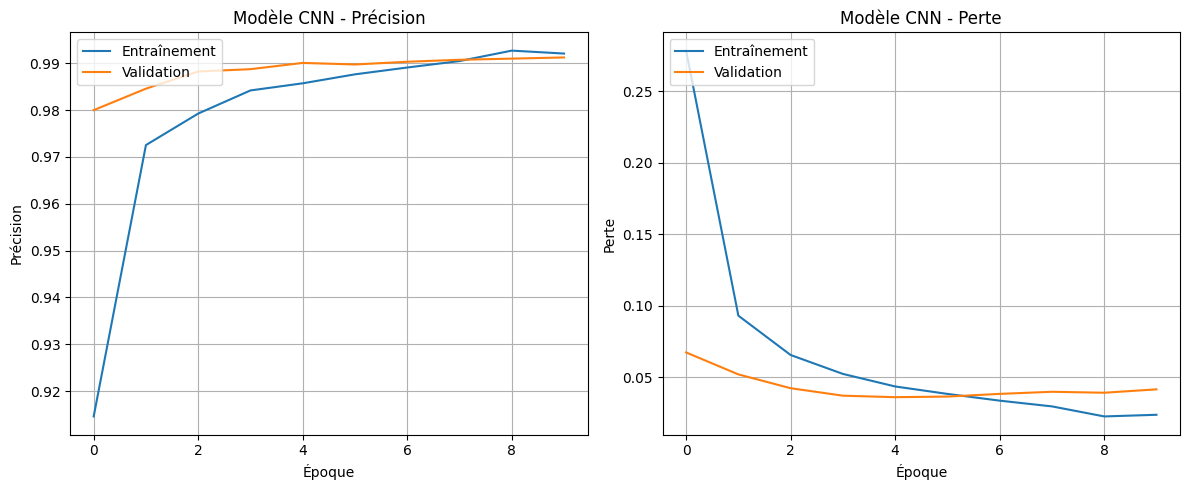

In [56]:
import matplotlib.pyplot as plt

# Plotting accuracy and loss for CNN
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title('Modèle CNN - Précision')
plt.ylabel('Précision')
plt.xlabel('Époque')
plt.legend(['Entraînement', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title('Modèle CNN - Perte')
plt.ylabel('Perte')
plt.xlabel('Époque')
plt.legend(['Entraînement', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()

### Analyse des erreurs de prédiction du modèle CNN

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Obtenir les prédictions du modèle CNN sur le dataset de test
predictions_cnn = model_cnn.predict(x_test_cnn_normalized)

# Convertir les prédictions (probabilités) en classes prédites (indices)
predicted_classes_cnn = np.argmax(predictions_cnn, axis=1)

# Convertir les vraies étiquettes (one-hot encoded) en classes numériques
true_classes_cnn = np.argmax(y_test_cnn_one_hot, axis=1)

print(f"Premières 10 prédictions: {predicted_classes_cnn[:10]}")
print(f"Premières 10 vraies étiquettes: {true_classes_cnn[:10]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Premières 10 prédictions: [7 2 1 0 4 1 4 9 5 9]
Premières 10 vraies étiquettes: [7 2 1 0 4 1 4 9 5 9]


In [59]:
# Trouver les indices des prédictions incorrectes
misclassified_indices = np.where(predicted_classes_cnn != true_classes_cnn)[0]

print(f"Nombre total d'échantillons mal classés par le CNN: {len(misclassified_indices)}")
print(f"Taux d'erreur du CNN: {len(misclassified_indices) / len(x_test_cnn_normalized):.4f}")

Nombre total d'échantillons mal classés par le CNN: 83
Taux d'erreur du CNN: 0.0083


#### Visualisation de quelques échantillons mal classés

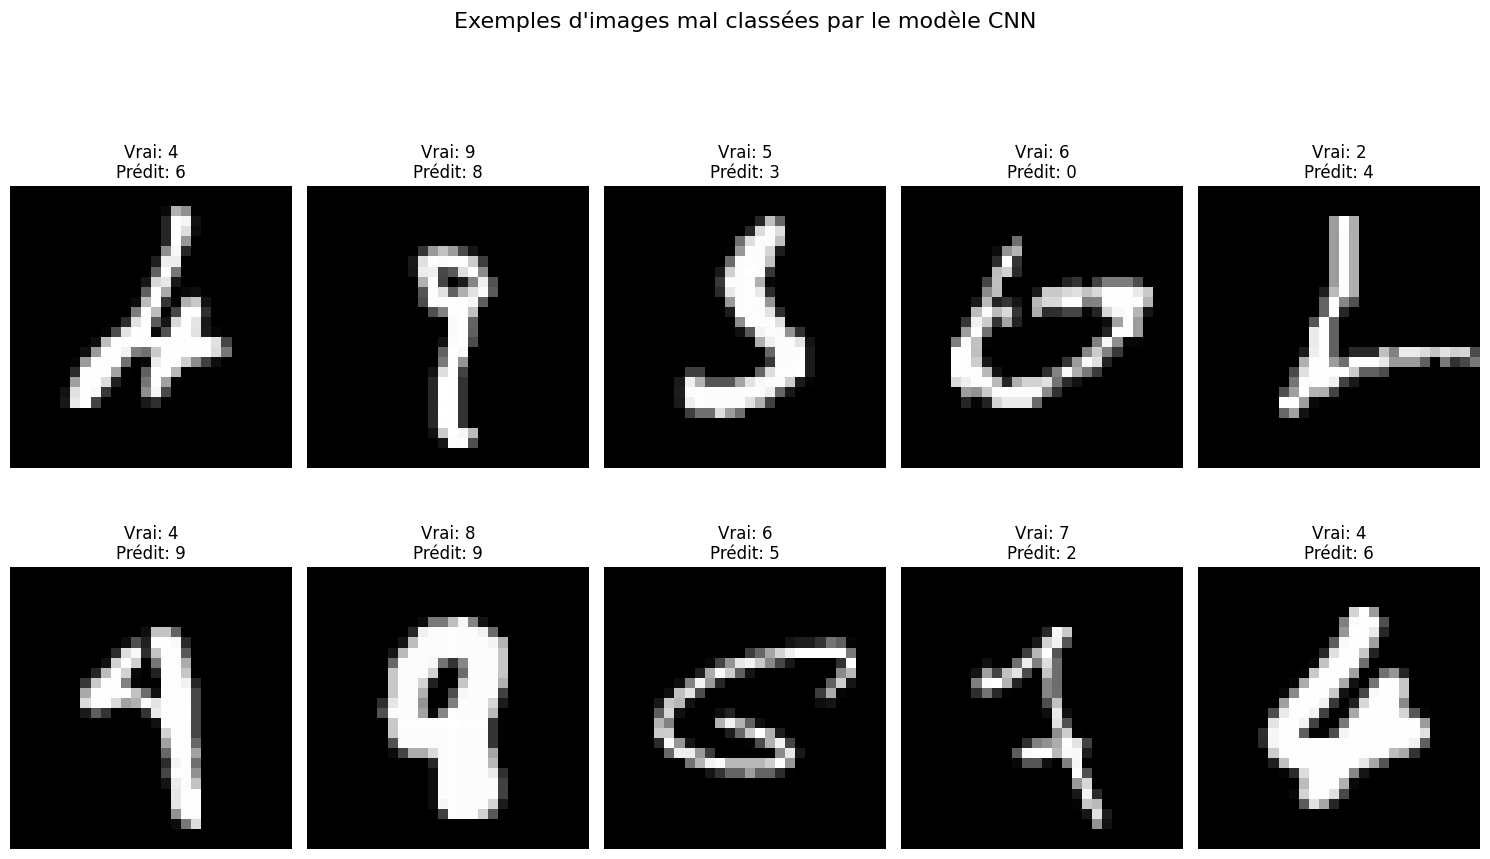

In [60]:
# Visualiser les 10 premiers échantillons mal classés

plt.figure(figsize=(15, 10))
for i, bad_index in enumerate(misclassified_indices[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[bad_index], cmap='gray') # x_test contient les images originales non normalisées
    plt.title(f"Vrai: {true_classes_cnn[bad_index]}\nPrédit: {predicted_classes_cnn[bad_index]}")
    plt.axis('off')
plt.suptitle('Exemples d\'images mal classées par le modèle CNN', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()